Trial 100 Complete [00h 01m 33s]
val_loss: 0.045999012887477875

Best val_loss So Far: 0.040449317544698715
Total elapsed time: 03h 02m 11s


c:\Users\Administrator\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Optimal Hyperparameters Found:
  - lstm_1_units: 256
  - dropout_1: 0.2
  - lstm_2_units: 128
  - dropout_2: 0.1
  - dense_units: 64
  - learning_rate: 0.01
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step

--- Tuned LSTM Continuous Performance ---
MAE:  4.6010
RMSE: 8.5444
R2:   0.7789

Weighted F1-Score: 0.9215

                                precision    recall  f1-score   support

                          Good       0.93      0.94      0.94       731
                          Fair       0.90      0.89      0.89       429
Unhealthy for Sensitive Groups       1.00      0.50      0.67         2

                      accuracy                           0.92      1162
                     macro avg       0.94      0.78      0.83      1162
                  weighted avg       0.92      0.92      0.92      1162



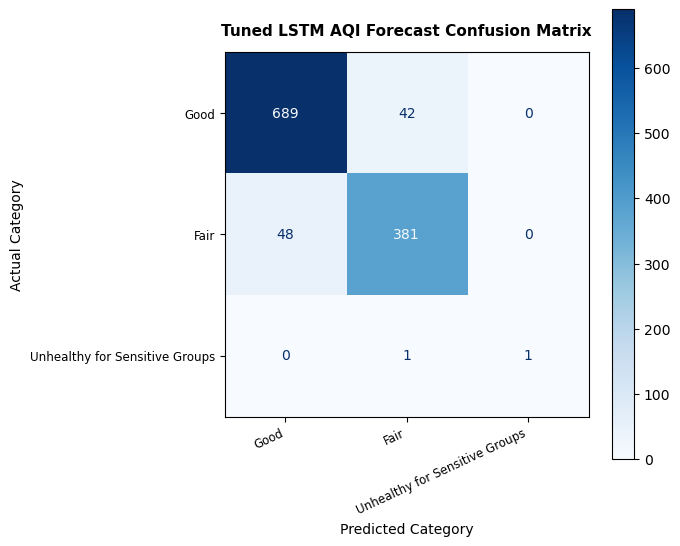

In [2]:
# !pip install keras-tuner

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import keras_tuner as kt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix, 
    mean_absolute_error, r2_score, root_mean_squared_error, f1_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# -------------------------------------------------------------
# 1. Load Data
# -------------------------------------------------------------
df = pd.read_csv('augmented_pollutant_data.csv', low_memory=False)
df.rename(columns={'date': 'Date', 'aqi': 'AQI'}, inplace=True)
df = df.dropna(subset=['Date', 'AQI']).copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# -------------------------------------------------------------
# 2. Cyclical Temporal Features
# -------------------------------------------------------------
df['sin_doy'] = np.sin(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['cos_doy'] = np.cos(2 * np.pi * df['Date'].dt.dayofyear / 365.25)
df['sin_dow'] = np.sin(2 * np.pi * df['Date'].dt.dayofweek / 7)
df['cos_dow'] = np.cos(2 * np.pi * df['Date'].dt.dayofweek / 7)

# Target (AQI) placed at index 0 for easy extraction
features = ['AQI', 'pm2.5', 'pm10', 'so2', 'nox', 'o3', 'co', 'sin_doy', 'cos_doy', 'sin_dow', 'cos_dow']

# -------------------------------------------------------------
# 3. Train-Test Split
# -------------------------------------------------------------
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# -------------------------------------------------------------
# 4. Independent Scaling & Imputation
# -------------------------------------------------------------
train_medians = train_df[features].median()
train_df[features] = train_df[features].ffill().fillna(train_medians)
test_df[features] = test_df[features].ffill().fillna(train_medians)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler() # Isolated scaler for inverse transform

train_scaled_X = scaler_X.fit_transform(train_df[features])
train_scaled_y = scaler_y.fit_transform(train_df[['AQI']])

test_scaled_X = scaler_X.transform(test_df[features])
test_scaled_y = scaler_y.transform(test_df[['AQI']])

# -------------------------------------------------------------
# 5. Native Sequence Generation (3D Tensors)
# -------------------------------------------------------------
def create_sequences(X_data, y_data, seq_length):
    X, y = [], []
    for i in range(len(X_data) - seq_length):
        X.append(X_data[i:(i + seq_length)])
        y.append(y_data[i + seq_length]) # Target t+1
    return np.array(X), np.array(y)

SEQ_LENGTH = 7
X_train, y_train = create_sequences(train_scaled_X, train_scaled_y, SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled_X, test_scaled_y, SEQ_LENGTH)

# -------------------------------------------------------------
# 6. Keras Tuner Architecture Definition
# -------------------------------------------------------------
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
    
    # Dynamically tune the first LSTM layer and Dropout
    model.add(LSTM(
        units=hp.Int('lstm_1_units', min_value=128, max_value=256, step=64),
        return_sequences=True
    ))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)))
    
    # Dynamically tune the second LSTM layer and Dropout
    model.add(LSTM(
        units=hp.Int('lstm_2_units', min_value=64, max_value=128, step=32),
        return_sequences=False
    ))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)))
    
    # Dynamically tune the Dense hidden layer
    model.add(Dense(
        units=hp.Int('dense_units', min_value=32, max_value=64, step=16),
        activation="relu"
    ))
    model.add(Dense(1, activation="linear"))

    # Dynamically tune the Adam optimizer learning rate
    hp_lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4, 1e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=hp_lr),
        loss="mae",  
        metrics=["mae", "mse"]
    )
    return model

# -------------------------------------------------------------
# 7. Execute Hyperparameter Search
# -------------------------------------------------------------
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=100,  # Number of hyperparameter combinations to test
    executions_per_trial=1,
    directory='lstm_tuning_dir',
    project_name='aqi_forecast',
    overwrite=True
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("Executing LSTM Hyperparameter Search...")
tuner.search(
    X_train, y_train,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Extract the optimal tuned model
best_model = tuner.get_best_models(num_models=1)[0]
print("\nOptimal Hyperparameters Found:")
for param, value in tuner.get_best_hyperparameters(num_trials=1)[0].values.items():
    print(f"  - {param}: {value}")

# -------------------------------------------------------------
# 8. Reverse Transformation & R2 Score
# -------------------------------------------------------------
y_pred_scaled = best_model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_inv = scaler_y.inverse_transform(y_test).flatten()

print('\n--- Tuned LSTM Continuous Performance ---')
print(f'MAE:  {mean_absolute_error(y_test_inv, y_pred):.4f}')
print(f'RMSE: {root_mean_squared_error(y_test_inv, y_pred):.4f}')
print(f'R2:   {r2_score(y_test_inv, y_pred):.4f}')

# -------------------------------------------------------------
# 9. Regulatory Categorization & F1 Score
# -------------------------------------------------------------
CATEGORY_BINS = [-np.inf, 50, 100, 150, 200, 300, np.inf]
CATEGORY_LABELS = ['Good', 'Fair', 'Unhealthy for Sensitive Groups', 'Very Unhealthy', 'Acutely Unhealthy', 'Emergency']

y_test_cat = pd.cut(y_test_inv, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
y_pred_cat = pd.cut(y_pred, bins=CATEGORY_BINS, labels=CATEGORY_LABELS, right=True).astype(str)
present_labels = [label for label in CATEGORY_LABELS if (y_test_cat == label).any()]

weighted_f1 = f1_score(y_test_cat, y_pred_cat, labels=present_labels, average='weighted', zero_division=0)
print(f'\nWeighted F1-Score: {weighted_f1:.4f}\n')
print(classification_report(y_test_cat, y_pred_cat, labels=present_labels, zero_division=0))

# -------------------------------------------------------------
# 10. Confusion Matrix Plot
# -------------------------------------------------------------
cm = confusion_matrix(y_test_cat, y_pred_cat, labels=present_labels)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Tuned LSTM AQI Forecast Confusion Matrix', fontsize=11, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=10)
plt.xlabel('Predicted Category', fontsize=10)
plt.xticks(rotation=25, ha='right', fontsize=8.5)
plt.yticks(fontsize=8.5)
plt.tight_layout()
plt.savefig('lstm_tuned_AQI_confusion_matrix.png', dpi=300)
plt.show()